In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

print("Carregando os dados...")
df = pd.read_csv('../../data/processed/preprocessed_1.csv')

X = df.drop('classe', axis=1)  # As 9 posições do tabuleiro (pos_1 .. pos_9)
y = df['classe']               # As 4 classes

print(f"Dataset: {df.shape[0]} amostras, {df.shape[1]-1} features")
print("\nDistribuição das classes:")
print(y.value_counts())

Carregando os dados...
Dataset: 1600 amostras, 9 features

Distribuição das classes:
classe
X venceu    626
Tem jogo    626
O venceu    316
Empate       32
Name: count, dtype: int64


In [3]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"Classes mapeadas: {list(le.classes_)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"\nTamanho do Treino: {len(X_train)} amostras")
print(f"Tamanho do Teste:  {len(X_test)} amostras")

Classes mapeadas: ['Empate', 'O venceu', 'Tem jogo', 'X venceu']

Tamanho do Treino: 1280 amostras
Tamanho do Teste:  320 amostras


In [4]:
param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf':  [1, 2],
    'class_weight':      ['balanced', None]
}

rf_base = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

print("Iniciando GridSearchCV...")
grid_search.fit(X_train, y_train)

print(f"\nMelhores parâmetros encontrados:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nMelhor F1 (CV): {grid_search.best_score_:.4f}")

Iniciando GridSearchCV...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Melhores parâmetros encontrados:
  class_weight: balanced
  max_depth: None
  min_samples_leaf: 1
  min_samples_split: 5
  n_estimators: 200

Melhor F1 (CV): 0.9132


In [5]:
rf_model = RandomForestClassifier(**grid_search.best_params_, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

# Acurácia no treino vs teste para checar overfitting
acc_treino = rf_model.score(X_train, y_train)
acc_teste  = rf_model.score(X_test,  y_test)
print(f"Acurácia no Treino: {acc_treino:.4f}")
print(f"Acurácia no Teste:  {acc_teste:.4f}")

if acc_treino - acc_teste > 0.05:
    print("\n⚠️  Diferença > 5pp entre treino e teste — possível overfitting.")
else:
    print("\n✅  Diferença treino/teste dentro do esperado.")

Acurácia no Treino: 0.9969
Acurácia no Teste:  0.9406

⚠️  Diferença > 5pp entre treino e teste — possível overfitting.


## 5. Avaliação: Relatório de Classificação e Matriz de Confusão

--- RELATÓRIO DE CLASSIFICAÇÃO ---
              precision    recall  f1-score   support

      Empate       0.86      0.86      0.86         7
    O venceu       0.93      1.00      0.96        63
    Tem jogo       1.00      0.86      0.92       125
    X venceu       0.91      1.00      0.95       125

    accuracy                           0.94       320
   macro avg       0.92      0.93      0.92       320
weighted avg       0.95      0.94      0.94       320



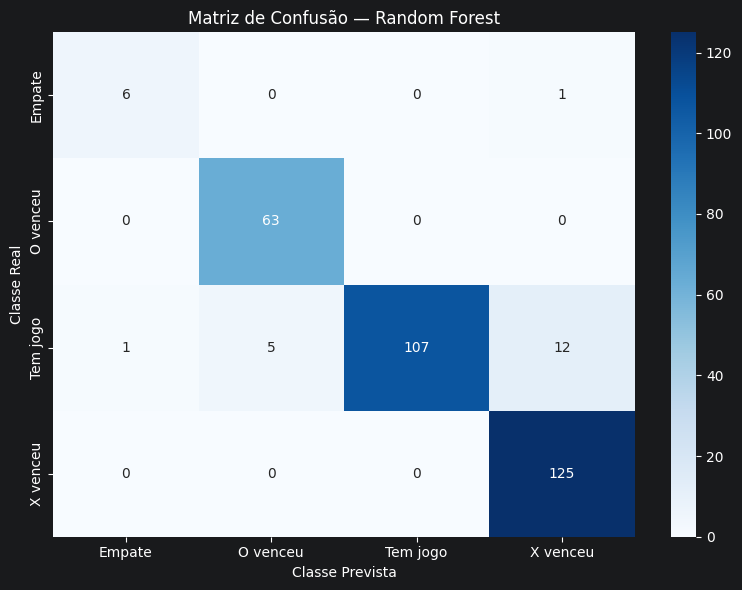

In [6]:
y_test_labels = le.inverse_transform(y_test)
y_pred_labels = le.inverse_transform(y_pred)

print("--- RELATÓRIO DE CLASSIFICAÇÃO ---")
print(classification_report(y_test_labels, y_pred_labels))

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_labels, y_pred_labels, labels=le.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusão — Random Forest')
plt.ylabel('Classe Real')
plt.xlabel('Classe Prevista')
plt.tight_layout()
plt.show()

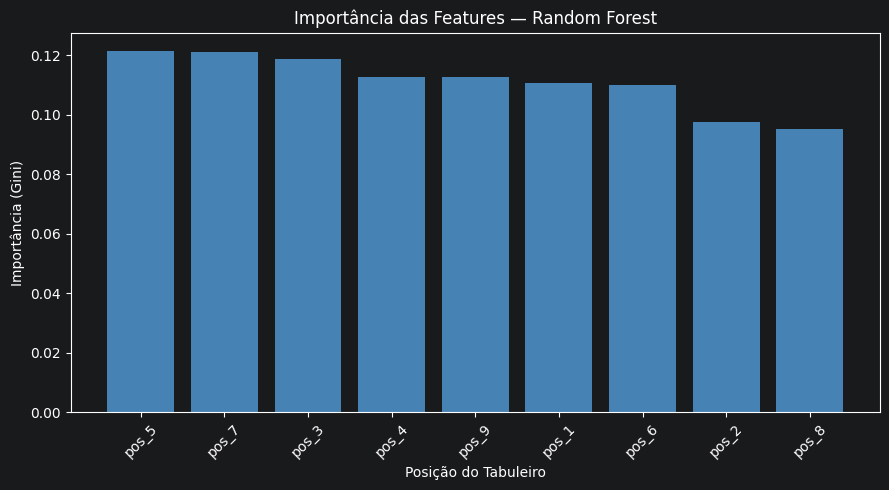


Importância por posição (ordenada):
  pos_5: 0.1215
  pos_7: 0.1212
  pos_3: 0.1188
  pos_4: 0.1126
  pos_9: 0.1125
  pos_1: 0.1106
  pos_6: 0.1101
  pos_2: 0.0974
  pos_8: 0.0952


In [7]:
importancias = rf_model.feature_importances_
features = X.columns.tolist()

indices_ordenados = np.argsort(importancias)[::-1]

plt.figure(figsize=(9, 5))
plt.bar(
    [features[i] for i in indices_ordenados],
    importancias[indices_ordenados],
    color='steelblue'
)
plt.title('Importância das Features — Random Forest')
plt.xlabel('Posição do Tabuleiro')
plt.ylabel('Importância (Gini)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nImportância por posição (ordenada):")
for i in indices_ordenados:
    print(f"  {features[i]}: {importancias[i]:.4f}")

In [8]:
os.makedirs('../../models/RandomForest', exist_ok=True)

joblib.dump(rf_model, '../../models/RandomForest/rf_model.pkl')
joblib.dump(le,       '../../models/RandomForest/rf_label_encoder.pkl')

print("Modelo e Encoder salvos com sucesso!")
print("  -> ../../models/RandomForest/rf_model.pkl")
print("  -> ../../models/RandomForest/rf_label_encoder.pkl")

Modelo e Encoder salvos com sucesso!
  -> ../../models/RandomForest/rf_model.pkl
  -> ../../models/RandomForest/rf_label_encoder.pkl
